# StructLTL preprocessing timings

Run both timing scripts first:

```bash
pixi run python scripts/time_structltl_preprocessing.py --repetitions 10
pixi run python scripts/time_structltl_forward.py
```

They write the summary CSVs consumed below.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').is_dir():
    ROOT = ROOT.parent
results = pd.read_csv(ROOT / 'scripts' / 'structltl_preprocessing_timings.csv')
forward_results = pd.read_csv(ROOT / 'scripts' / 'structltl_forward_timings.csv')
results, forward_results

(   formula_length  num_measurements  ldba_mean_seconds  ldba_std_seconds  \
 0               2                99           0.354117          0.026083   
 1               4                99           0.373534          0.027670   
 2               8                99           0.398709          0.025845   
 3              12                99           0.420964          0.025354   
 
    boolean_generation_mean_seconds  boolean_generation_std_seconds  
 0                         0.003023                        0.009532  
 1                         0.003178                        0.008654  
 2                         0.006288                        0.009963  
 3                         0.012818                        0.010164  ,
    formula_length                           formula_file  formula_index  \
 0               2   conf/formulas/warehouse/reach-2.yaml              1   
 1               4   conf/formulas/warehouse/reach-4.yaml              1   
 2               8   conf/formulas

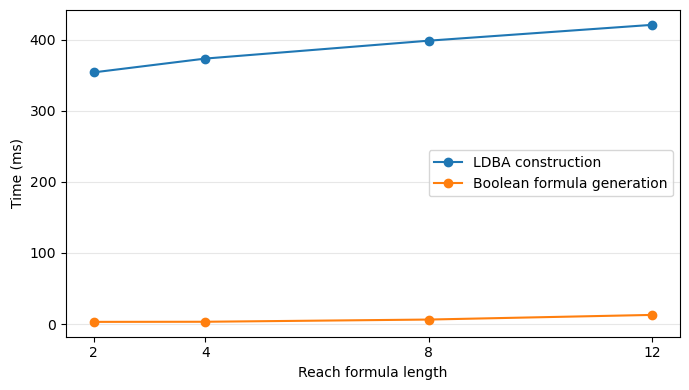

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
series = [
    ('LDBA construction', 'ldba_mean_seconds'),
    ('Boolean formula generation', 'boolean_generation_mean_seconds'),
]
for label, mean_column in series:
    ax.plot(
        results['formula_length'], results[mean_column] * 1_000,
        marker='o', label=label,
    )
ax.set(xlabel='Reach formula length', ylabel='Time (ms)')
ax.set_xticks(results['formula_length'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()

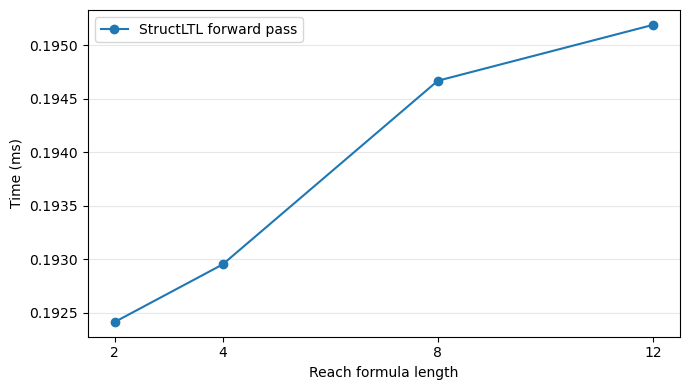

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    forward_results['formula_length'], forward_results['forward_mean_seconds'] * 1_000,
    marker='o', label='StructLTL forward pass',
)
ax.set(xlabel='Reach formula length', ylabel='Time (ms)')
ax.set_xticks(forward_results['formula_length'])
ax.grid(axis='y', alpha=0.3)
ax.legend()
fig.tight_layout()

In [11]:
forward_by_depth = forward_results.set_index('formula_length')
table = pd.DataFrame(
    {
        f"Depth {depth}": [
            round(row.ldba_mean_seconds * 1_000, 1),
            round(row.boolean_generation_mean_seconds * 1_000, 1),
            round(forward_by_depth.loc[depth, 'forward_mean_seconds'] * 1_000, 1),
        ]
        for depth, row in results.set_index('formula_length').sort_index().iterrows()
    },
    index=[
        'LDBA construction (ms)',
        'Boolean formula generation (ms)',
        'StructLTL forward pass (ms)',
    ],
)
markdown_table = table.rename_axis('Stage').reset_index()
print(markdown_table.to_markdown(index=False))
table

| Stage                           |   Depth 2 |   Depth 4 |   Depth 8 |   Depth 12 |
|:--------------------------------|----------:|----------:|----------:|-----------:|
| LDBA construction (ms)          |     354.1 |     373.5 |     398.7 |      421   |
| Boolean formula generation (ms) |       3   |       3.2 |       6.3 |       12.8 |
| StructLTL forward pass (ms)     |       0.2 |       0.2 |       0.2 |        0.2 |


,Depth 2,Depth 4,Depth 8,Depth 12
LDBA construction (ms),354.1,373.5,398.7,421.0
Boolean formula generation (ms),3.0,3.2,6.3,12.8
StructLTL forward pass (ms),0.2,0.2,0.2,0.2
